# Benchmark: DreaMS Spectrum-to-Spectrum (Approach A)

DreaMS pretrained embeddings + cosine search vs classical baselines from NB01. Both use precursor filtering (±0.5 Da).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=0.95)
plt.rcParams.update({
    "figure.figsize": (6, 2),
    "figure.dpi": 150,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "svg.fonttype": "none",
})

%matplotlib inline

## 1. Load Pre-computed Results

In [2]:
classical = pd.read_parquet("../data/benchmark_classical.parquet")
dreams = pd.read_parquet("../data/benchmark_dreams.parquet")

cosine_df = classical[classical["method"] == "cosine"]
results = pd.concat([cosine_df, dreams], ignore_index=True)

METHOD_LABELS = {"cosine": "Cosine (classical)", "dreams_s2s": "DreaMS (pretrained)"}
METHOD_COLORS = {"cosine": "#1f77b4", "dreams_s2s": "#ff7f0e"}
NOISE_ORDER = ["clean", "mild", "moderate", "severe", "extreme"]
SET_ORDER = ["0% isomer", "50% isomer", "100% isomer"]

print(f"Classical: {len(classical)} rows ({classical['method'].nunique()} methods)")
print(f"DreaMS:    {len(dreams)} rows")
print(f"Combined:  {len(results)} rows (cosine + dreams_s2s)")
print(results[["eval_set", "method", "noise", "top_1", "class_top_1", "mrr"]].to_string(index=False))

Classical: 75 rows (5 methods)
DreaMS:    15 rows
Combined:  30 rows (cosine + dreams_s2s)
   eval_set     method    noise  top_1  class_top_1      mrr
  0% isomer     cosine    clean   1.00         1.00 1.000000
  0% isomer     cosine     mild   0.99         0.99 0.995000
  0% isomer     cosine moderate   0.96         0.98 0.973333
  0% isomer     cosine   severe   0.79         0.84 0.840500
  0% isomer     cosine  extreme   0.43         0.59 0.553552
 50% isomer     cosine    clean   0.70         1.00 0.819750
 50% isomer     cosine     mild   0.70         1.00 0.818500
 50% isomer     cosine moderate   0.65         0.96 0.762845
 50% isomer     cosine   severe   0.53         0.80 0.615940
 50% isomer     cosine  extreme   0.22         0.41 0.308401
100% isomer     cosine    clean   0.41         1.00 0.647083
100% isomer     cosine     mild   0.39         0.99 0.630417
100% isomer     cosine moderate   0.36         0.96 0.581111
100% isomer     cosine   severe   0.21         0.75 0.3

## 2. Accuracy Degradation Under Noise

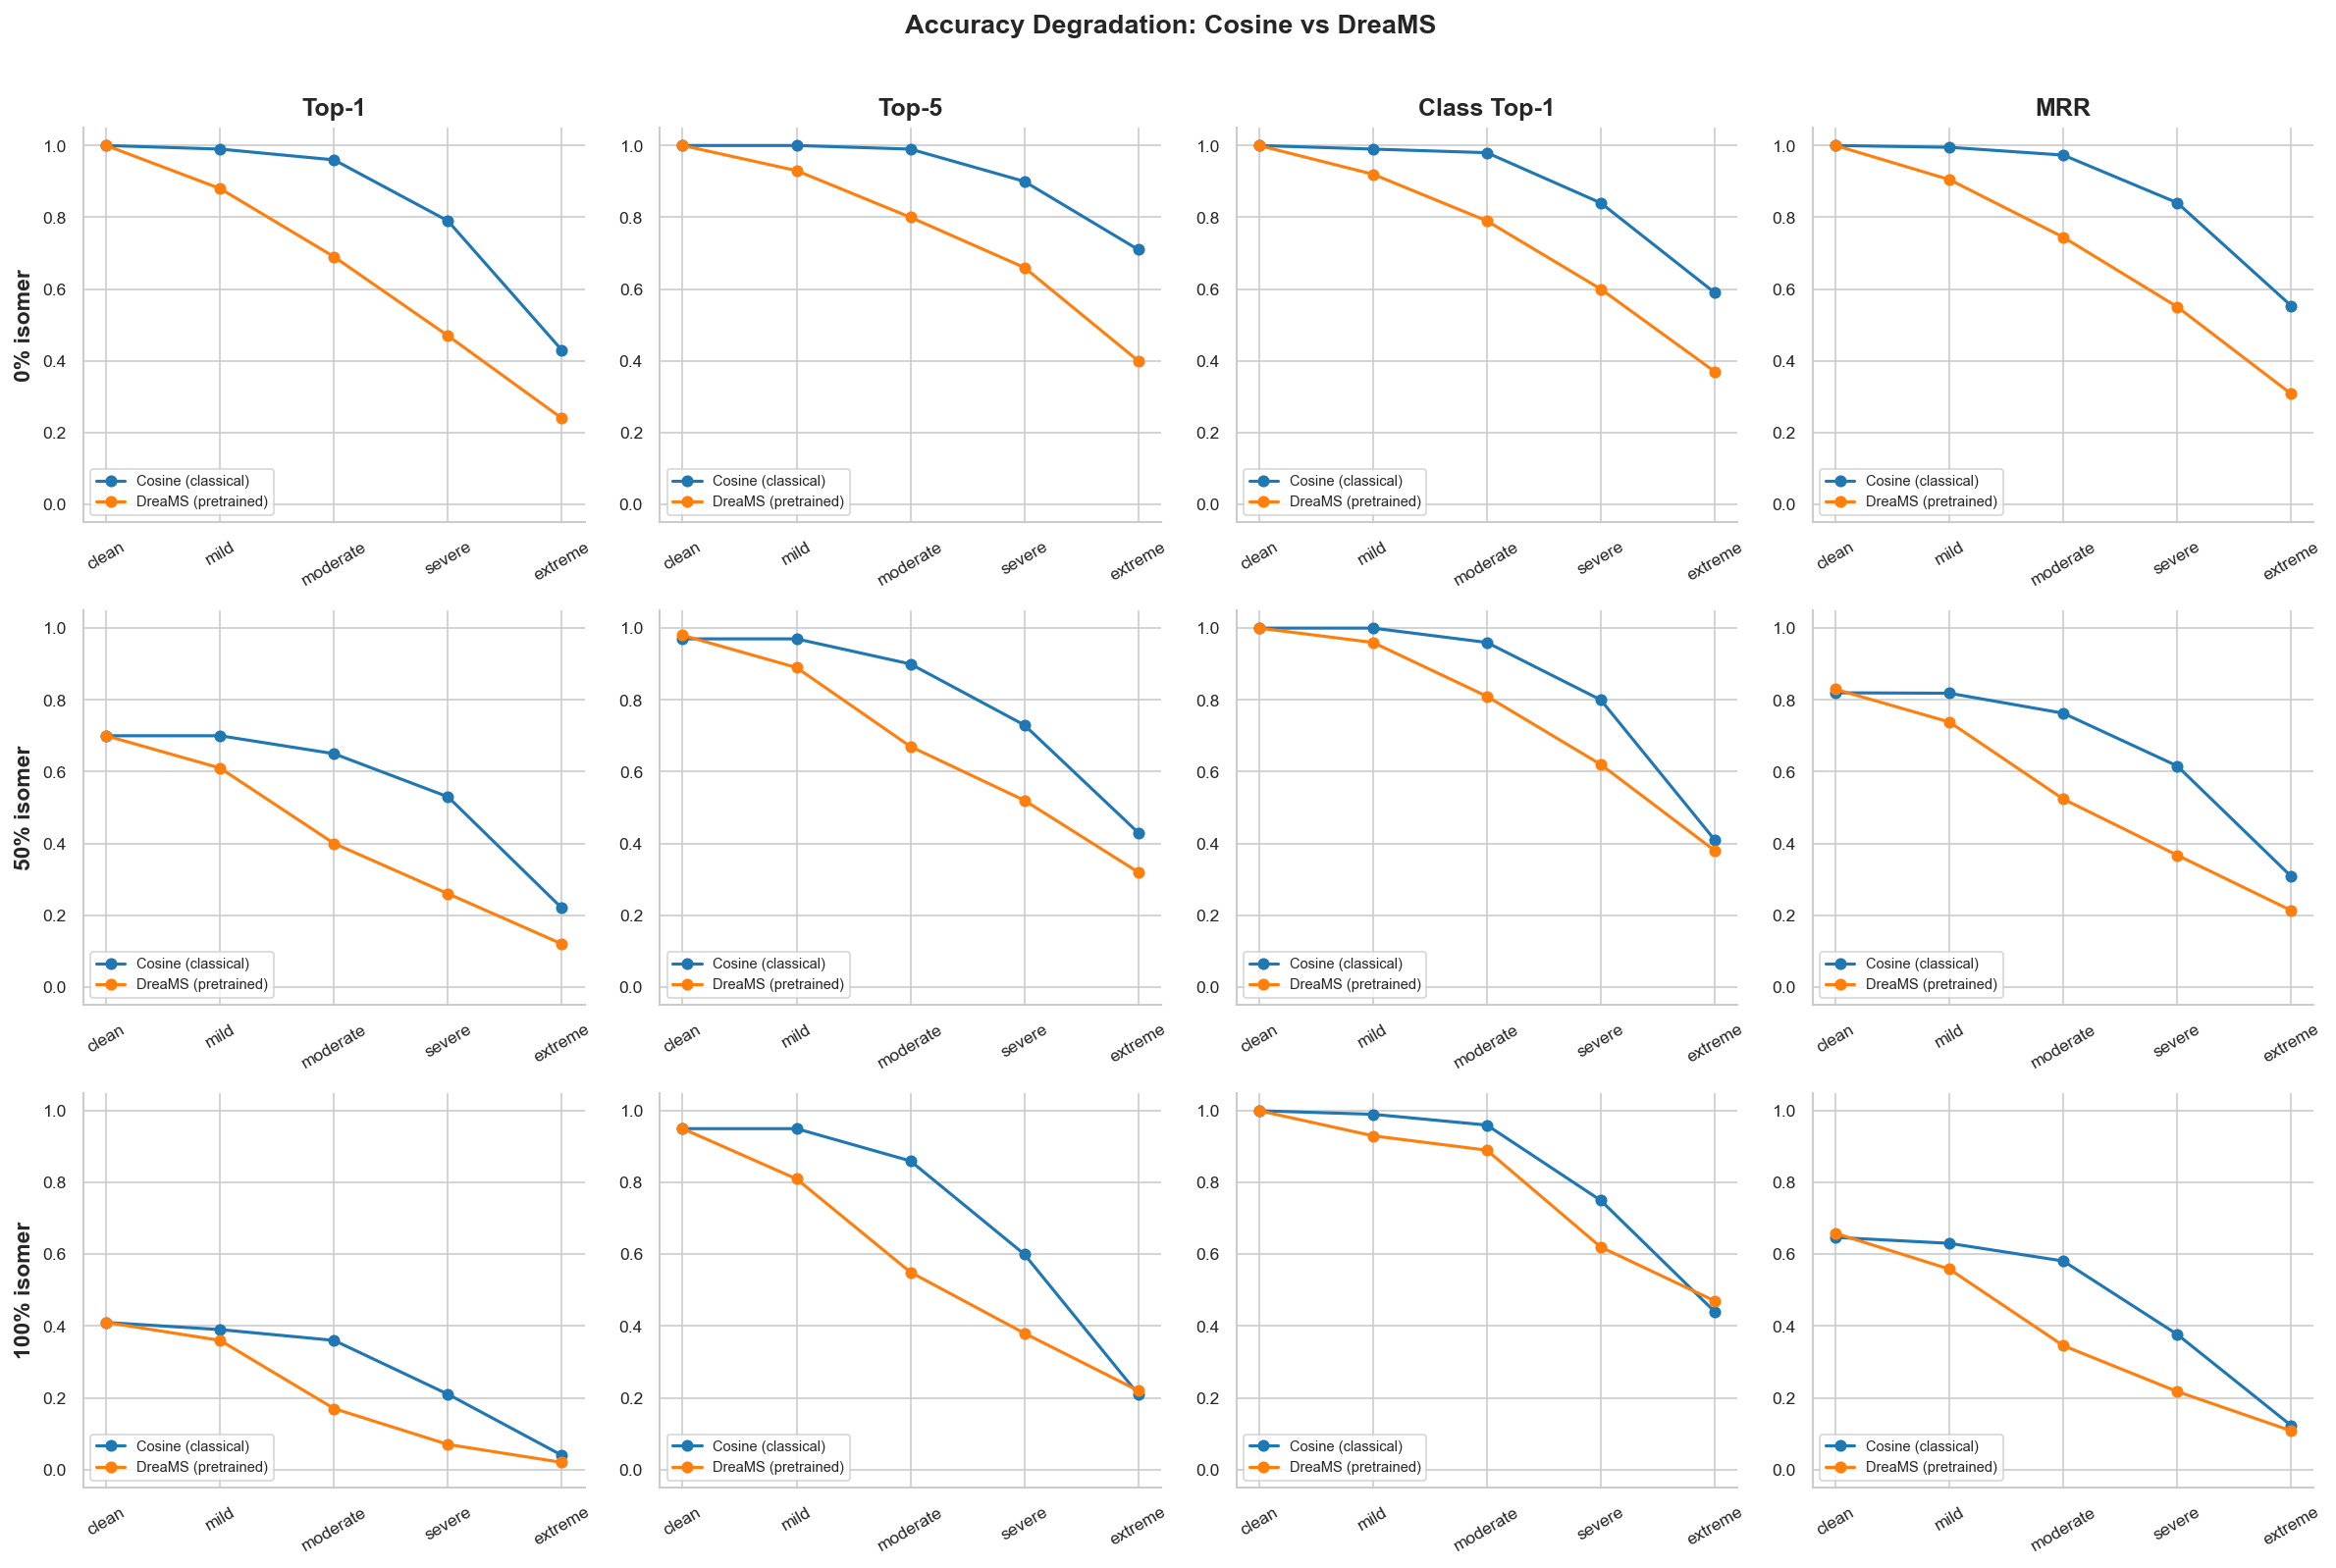

In [3]:
metrics = [("top_1", "Top-1"), ("top_5", "Top-5"), ("class_top_1", "Class Top-1"), ("mrr", "MRR")]

fig, axes = plt.subplots(len(SET_ORDER), len(metrics), figsize=(16, 3.5 * len(SET_ORDER)))

for row, eval_set in enumerate(SET_ORDER):
    subset = results[results["eval_set"] == eval_set]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in ["cosine", "dreams_s2s"]:
            m = subset[subset["method"] == method].set_index("noise").loc[NOISE_ORDER]
            ax.plot(
                NOISE_ORDER, m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method],
            )
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(eval_set, fontweight="bold", fontsize=11)
        ax.tick_params(axis="x", rotation=30)

plt.suptitle("Accuracy Degradation: Cosine vs DreaMS", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

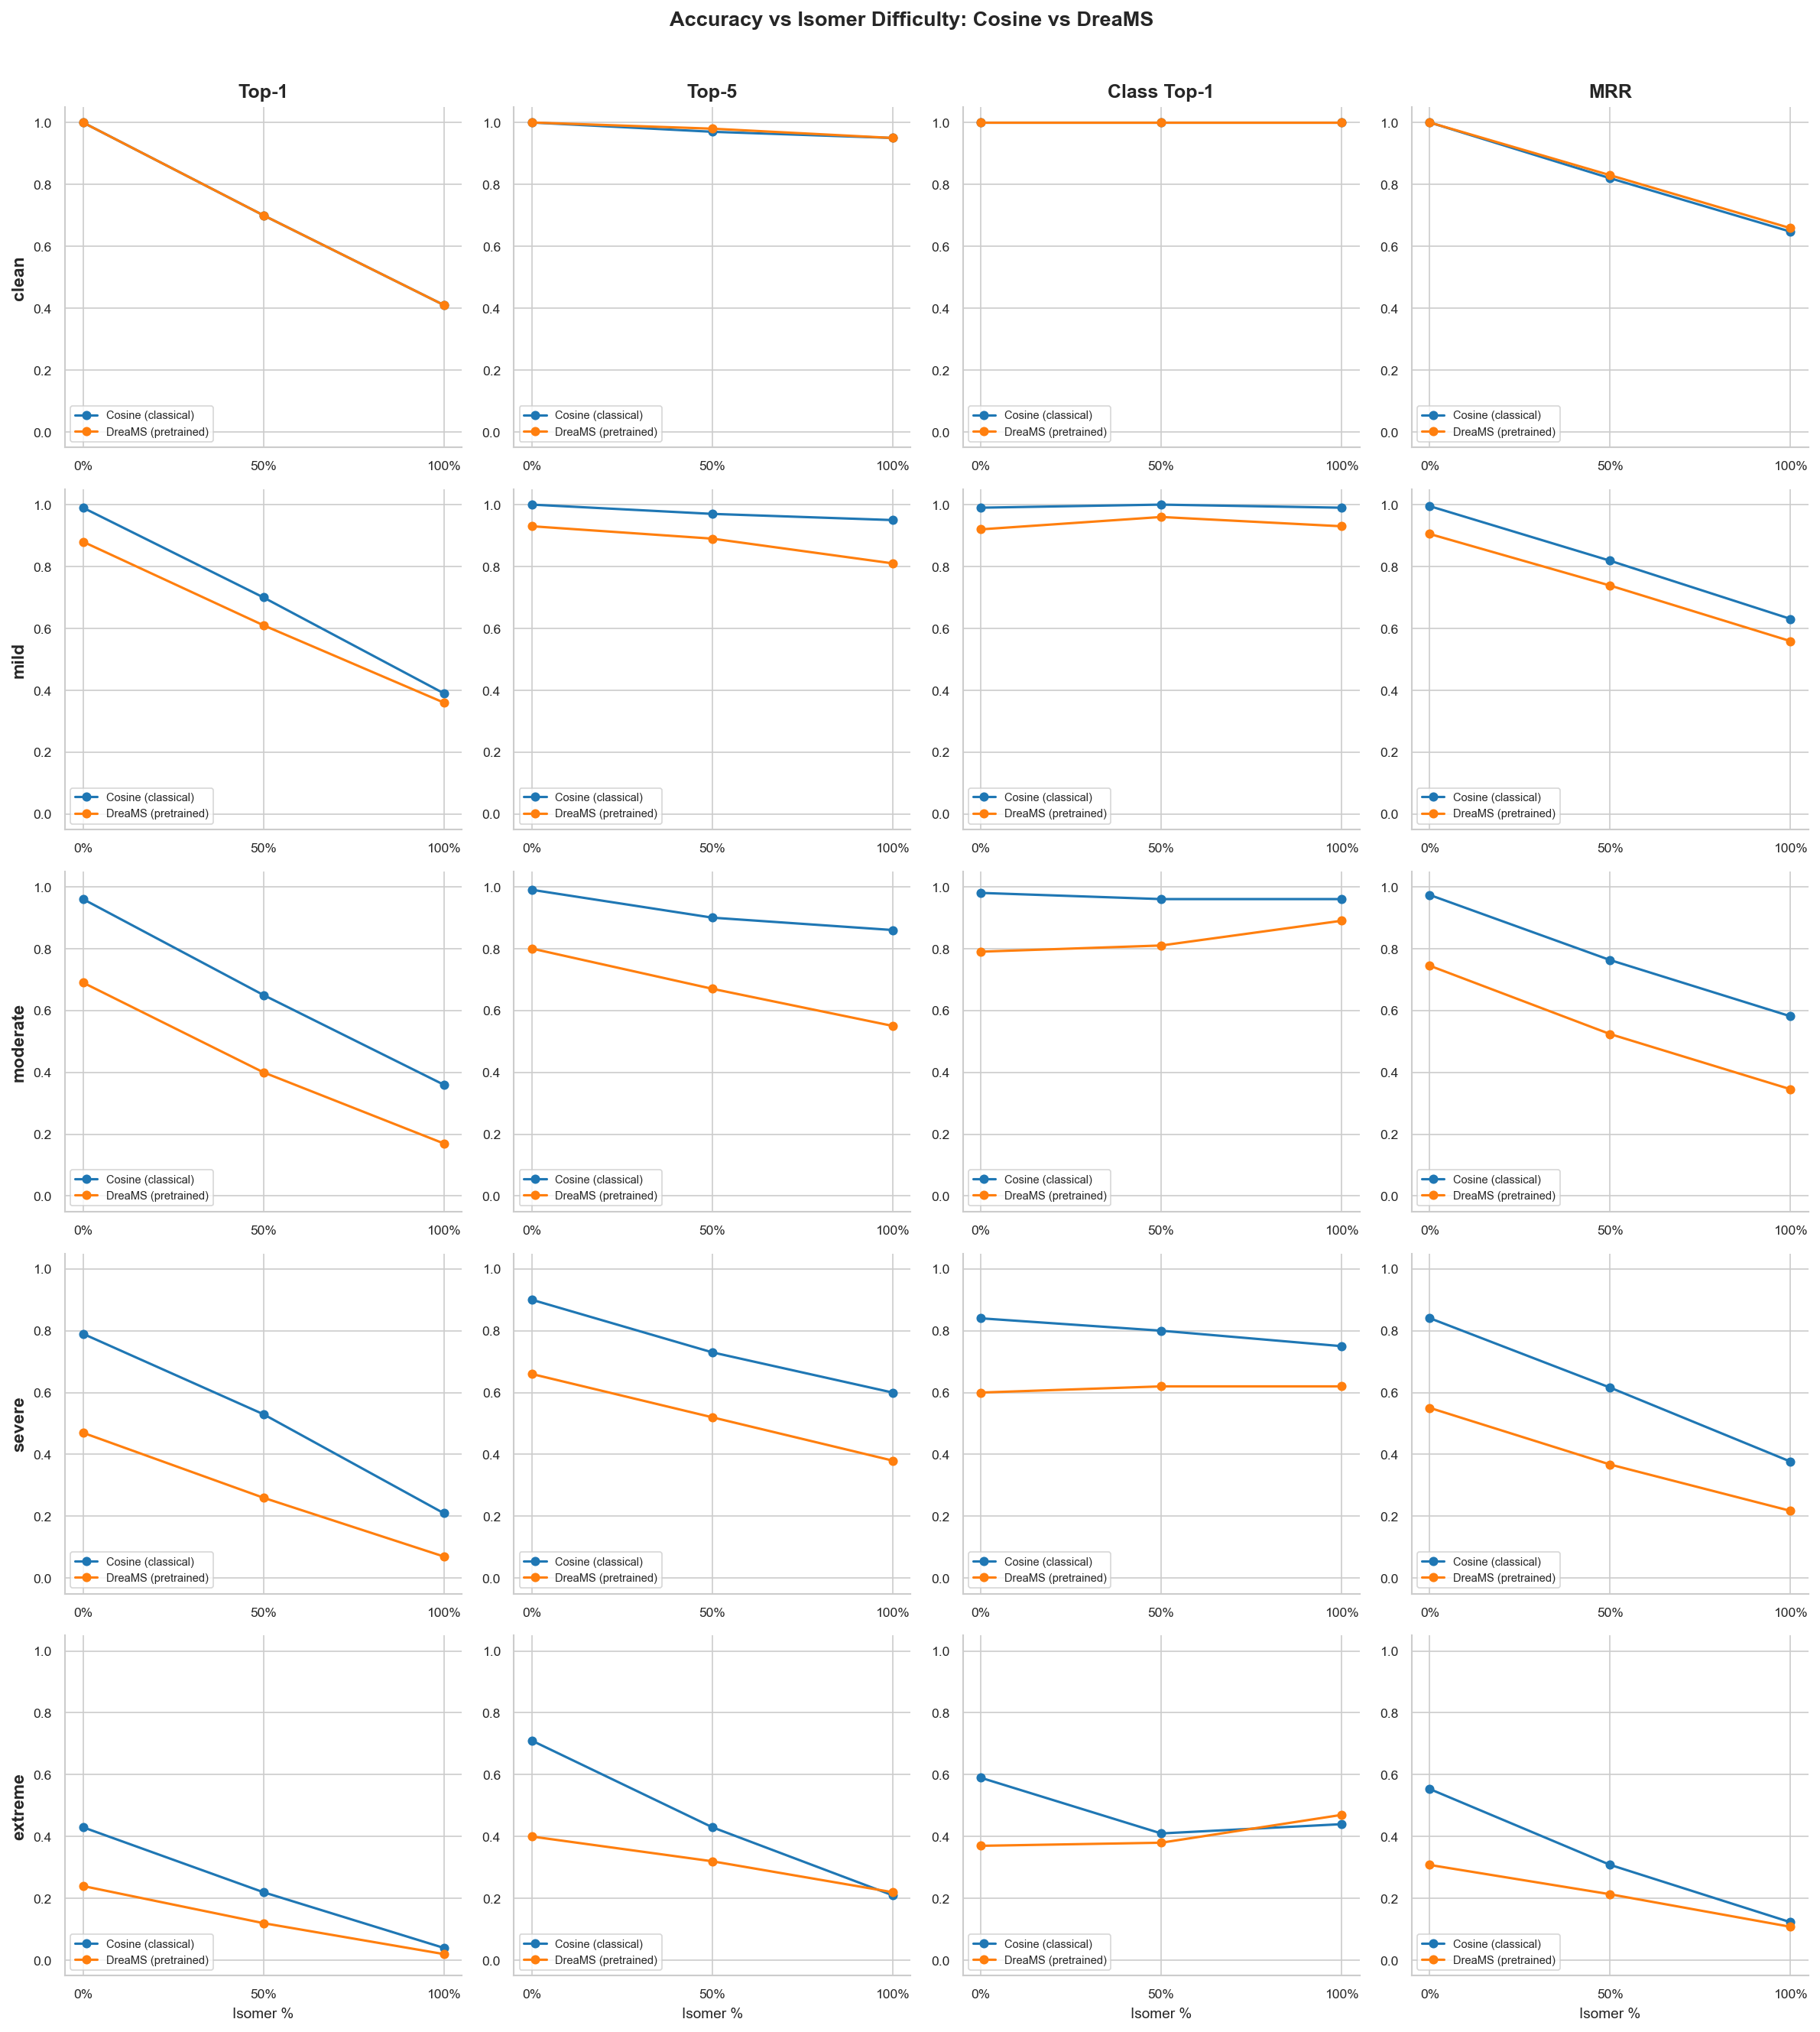

In [4]:
ISOMER_PCTS = [0, 50, 100]
set_to_pct = {"0% isomer": 0, "50% isomer": 50, "100% isomer": 100}
results["isomer_pct"] = results["eval_set"].map(set_to_pct)

fig, axes = plt.subplots(len(NOISE_ORDER), len(metrics), figsize=(16, 3.5 * len(NOISE_ORDER)))

for row, noise in enumerate(NOISE_ORDER):
    subset = results[results["noise"] == noise]
    for col, (metric, title) in enumerate(metrics):
        ax = axes[row, col]
        for method in ["cosine", "dreams_s2s"]:
            m = subset[subset["method"] == method].sort_values("isomer_pct")
            ax.plot(
                m["isomer_pct"], m[metric], marker="o", linewidth=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method],
            )
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(ISOMER_PCTS)
        ax.set_xticklabels(["0%", "50%", "100%"])
        ax.legend(fontsize=7, loc="lower left")
        if row == 0:
            ax.set_title(title, fontweight="bold")
        if col == 0:
            ax.set_ylabel(noise, fontweight="bold", fontsize=11)
        if row == len(NOISE_ORDER) - 1:
            ax.set_xlabel("Isomer %")

plt.suptitle("Accuracy vs Isomer Difficulty: Cosine vs DreaMS", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3. DreaMS Improvement Over Cosine

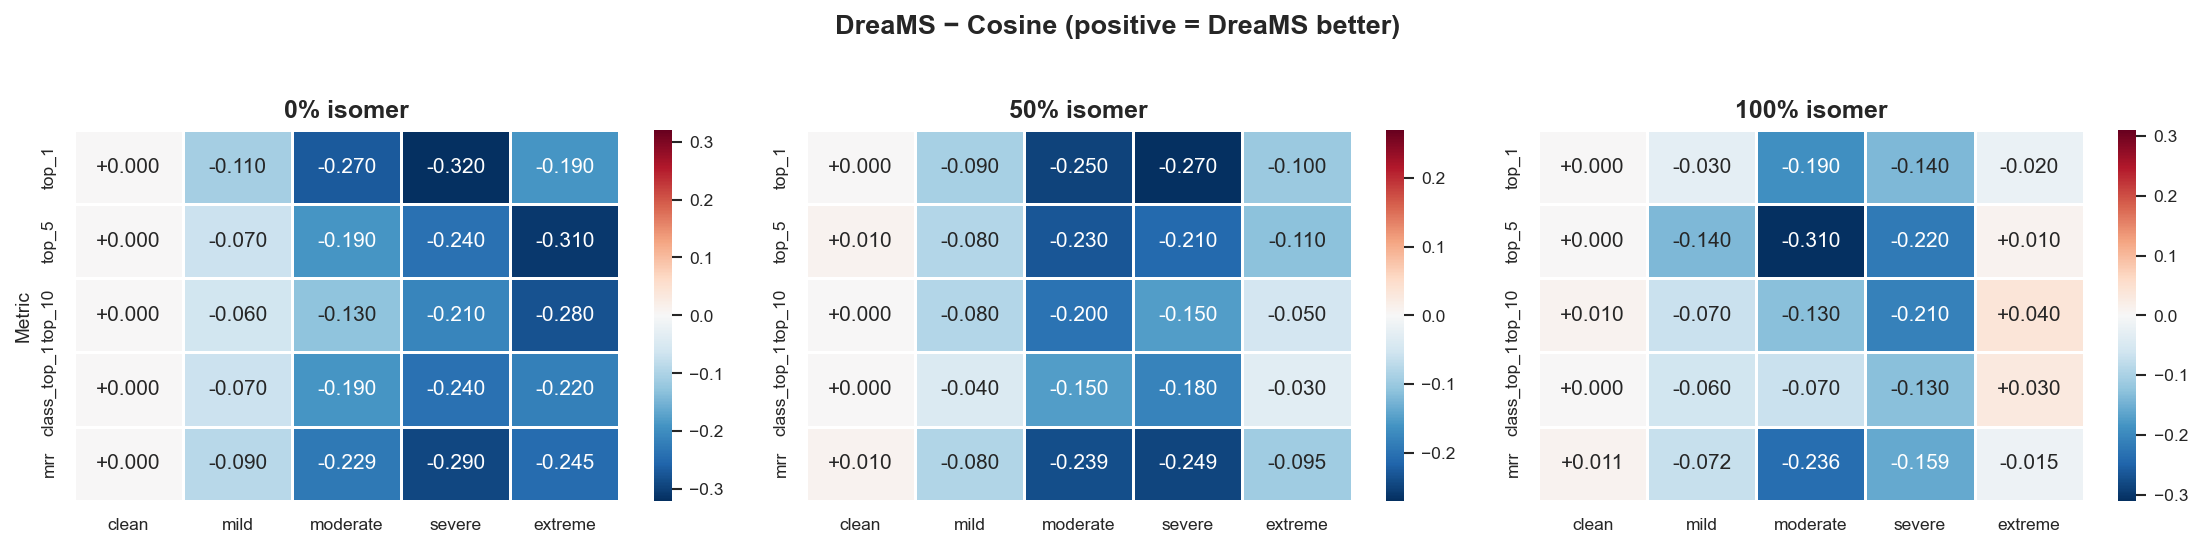

In [5]:
delta_rows = []
for eval_set in SET_ORDER:
    cos = results[(results["eval_set"] == eval_set) & (results["method"] == "cosine")].set_index("noise")
    drm = results[(results["eval_set"] == eval_set) & (results["method"] == "dreams_s2s")].set_index("noise")
    for noise in NOISE_ORDER:
        for metric in ["top_1", "top_5", "top_10", "class_top_1", "mrr"]:
            delta_rows.append({
                "eval_set": eval_set, "noise": noise, "metric": metric,
                "delta": drm.loc[noise, metric] - cos.loc[noise, metric],
            })
delta = pd.DataFrame(delta_rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for i, eval_set in enumerate(SET_ORDER):
    ax = axes[i]
    sub = delta[delta["eval_set"] == eval_set]
    pivot = sub.pivot(index="metric", columns="noise", values="delta")
    pivot = pivot.loc[["top_1", "top_5", "top_10", "class_top_1", "mrr"], NOISE_ORDER]
    vmax = max(0.1, abs(pivot.values).max())
    sns.heatmap(
        pivot, annot=True, fmt="+.3f", cmap="RdBu_r",
        center=0, vmin=-vmax, vmax=vmax, ax=ax,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(eval_set, fontweight="bold")
    ax.set_ylabel("" if i > 0 else "Metric")
    ax.set_xlabel("")

plt.suptitle("DreaMS \u2212 Cosine (positive = DreaMS better)", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## 4. Query Time

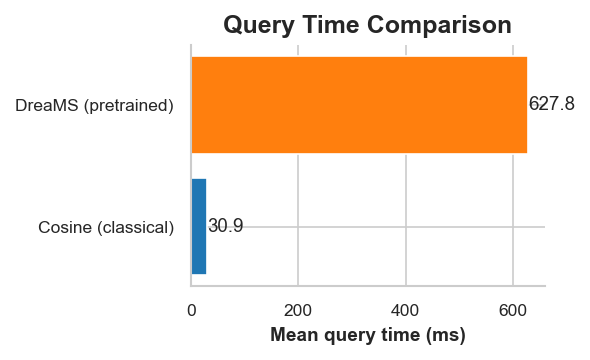

In [6]:
time_df = results.groupby("method")["mean_query_ms"].mean().reset_index()
time_df["label"] = time_df["method"].map(METHOD_LABELS)

fig, ax = plt.subplots(figsize=(4, 2.5))
bars = ax.barh(time_df["label"], time_df["mean_query_ms"], color=[METHOD_COLORS[m] for m in time_df["method"]])
ax.set_xlabel("Mean query time (ms)", fontweight="bold")
for bar, val in zip(bars, time_df["mean_query_ms"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=9)
ax.set_title("Query Time Comparison", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Why DreaMS Underperforms

DreaMS S2S retrieval underperforms cosine across all conditions. The root cause is compressed similarity margins — confusers score too close to correct matches in embedding space.

In [7]:
# Load DreaMS model and eval data (shared across all studies)
import torch
_original_torch_load = torch.load
def _patched_torch_load(*args, **kwargs):
    kwargs["weights_only"] = False
    return _original_torch_load(*args, **kwargs)
torch.load = _patched_torch_load

from dreams.api import PreTrainedModel
from src.data.loader import load_library
from src.data.evaluation import load_split_eval_sets
from src.models.dreams_pipeline import _embed_spectra, _normalize
from src.utils.spectrum import SpectralSimilarity

model = PreTrainedModel.from_name("DreaMS_embedding")
df = load_library()

# Load eval sets — use the no-isomer set for clean diagnostics
eval_no_iso, eval_mixed, eval_with_iso = load_split_eval_sets()
clean_queries = eval_no_iso["clean"]

# Pre-compute template keys and name index (used by margin analysis)
def intensity_key(ints):
    r = np.array(ints, dtype=np.float64)
    mx = r.max()
    if mx > 0:
        r = np.round(r / mx, 6)
    return tuple(r)

df["_template"] = df["intensity_list"].apply(intensity_key)
name_to_idx = {name: i for i, name in enumerate(df["name"])}

# Embed clean queries
clean_mz = [np.asarray(q["mz_list"]) for q in clean_queries]
clean_int = [np.asarray(q["intensity_list"]) for q in clean_queries]
clean_prec = [float(q["precursor_mz"]) for q in clean_queries]
clean_embs = _normalize(_embed_spectra(model, clean_mz, clean_int, clean_prec))

print(f"Library: {len(df):,} spectra")
print(f"Clean no-isomer queries: {len(clean_queries)}")
print(f"Clean embeddings shape: {clean_embs.shape}")

/home/weiyi/lipid_identification/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Removed 384 spectra with <2 peaks


Library: 551,890 spectra
Clean no-isomer queries: 100
Clean embeddings shape: (100, 1024)


### 5.1 Similarity Margin Analysis

Distribution of correct-match vs confuser similarity scores reveals the root cause: DreaMS correct-confuser gap is only ~0.32 while classical cosine achieves ~0.95 separation.

Embedding 582 unique candidates...


Correct: 30, Same-template: 61, Different-template: 491


/tmp/ipykernel_2489212/202535251.py:99: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(correct_classical, ax=ax, label="Correct match", color="#2ca02c", **kde_kw)


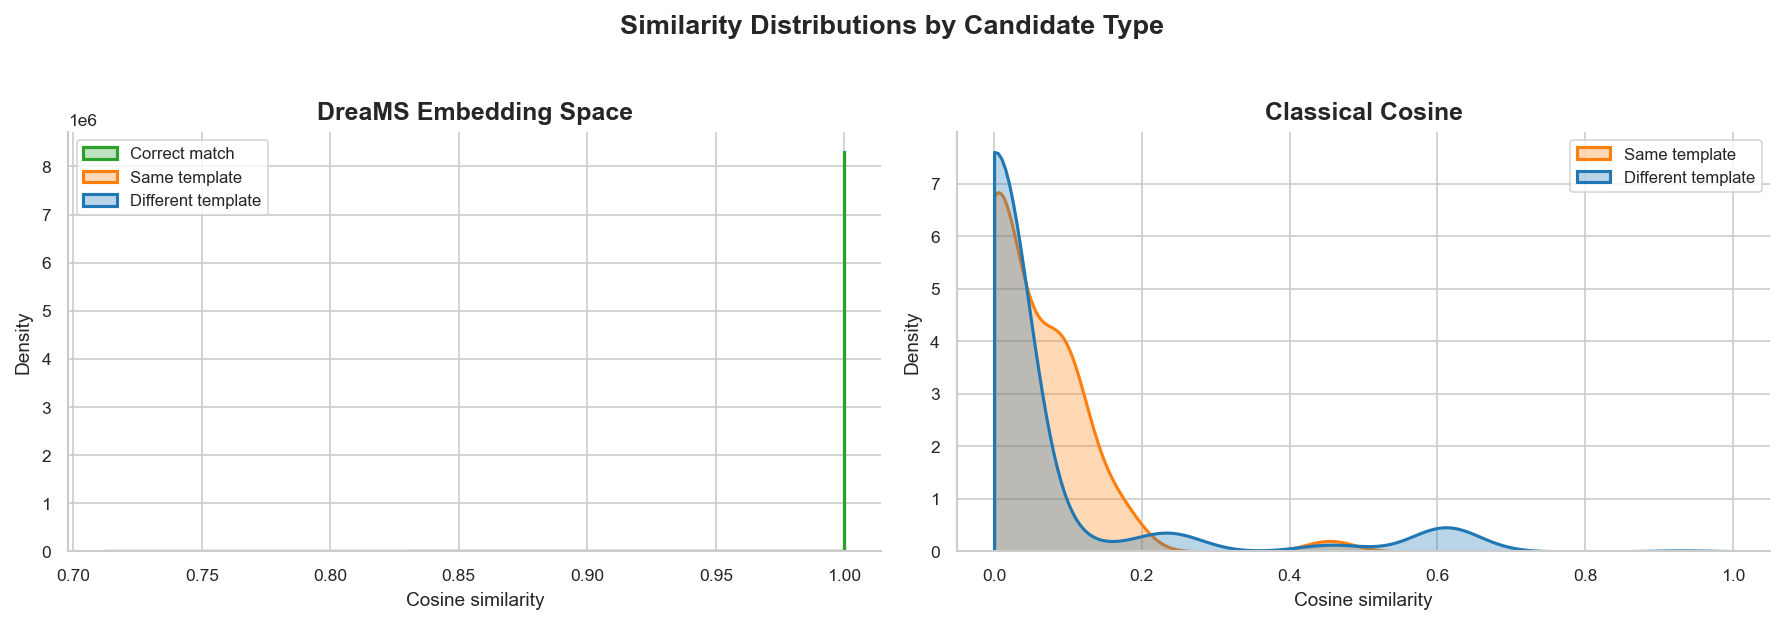


DreaMS    — correct mean: 1.000, same-template mean: 0.980, gap: +0.020
Classical — correct mean: 1.000, same-template mean: 0.052, gap: +0.948


In [8]:
from src.utils.indexing import PrecursorIndex

precursor_index = PrecursorIndex(df)
scorer = SpectralSimilarity("cosine")
rng = np.random.default_rng(42)

# Use 30 queries, sample ≤20 candidates per category per query to keep embedding count low
n_diag = 30
diag_queries = clean_queries[:n_diag]
diag_embs = clean_embs[:n_diag]
MAX_PER_CAT = 20

# Collect candidate indices to embed (deduplicated)
cand_set = set()
query_info = []  # (query_idx, gt_idx, gt_template, cand_indices_by_category)

for i in range(n_diag):
    q = diag_queries[i]
    gt_idx = name_to_idx[q["ground_truth_name"]]
    gt_template = df.iloc[gt_idx]["_template"]
    cands = precursor_index.query(q["precursor_mz"], q["mode"], 0.5)
    if len(cands) < 2:
        continue

    same_tpl = [c for c in cands if c != gt_idx and df.iloc[c]["_template"] == gt_template]
    diff_tpl = [c for c in cands if df.iloc[c]["_template"] != gt_template]

    if len(same_tpl) > MAX_PER_CAT:
        same_tpl = rng.choice(same_tpl, MAX_PER_CAT, replace=False).tolist()
    if len(diff_tpl) > MAX_PER_CAT:
        diff_tpl = rng.choice(diff_tpl, MAX_PER_CAT, replace=False).tolist()

    selected = [gt_idx] + same_tpl + diff_tpl
    cand_set.update(selected)
    query_info.append((i, gt_idx, gt_template, same_tpl, diff_tpl))

# Single batch embedding
unique_cands = sorted(cand_set)
cand_to_pos = {idx: j for j, idx in enumerate(unique_cands)}
print(f"Embedding {len(unique_cands)} unique candidates...")

cand_mz = [np.asarray(df.iloc[c]["mz_list"]) for c in unique_cands]
cand_int = [np.asarray(df.iloc[c]["intensity_list"]) for c in unique_cands]
cand_prec = [float(df.iloc[c]["precursor_mz"]) for c in unique_cands]
all_cand_embs = _normalize(_embed_spectra(model, cand_mz, cand_int, cand_prec))

# Score
correct_dreams, same_tpl_dreams, diff_tpl_dreams = [], [], []
correct_classical, same_tpl_classical, diff_tpl_classical = [], [], []

for qi, gt_idx, gt_template, same_list, diff_list in query_info:
    q = diag_queries[qi]
    q_emb = diag_embs[qi]

    for c_idx, bucket_d, bucket_c in [
        (gt_idx, correct_dreams, correct_classical),
    ]:
        bucket_d.append(float(q_emb @ all_cand_embs[cand_to_pos[c_idx]]))
        ref = {"mz_list": df.iloc[c_idx]["mz_list"],
               "intensity_list": df.iloc[c_idx]["intensity_list"],
               "precursor_mz": df.iloc[c_idx]["precursor_mz"]}
        bucket_c.append(scorer.score(q, ref)[0])

    for c_idx in same_list:
        same_tpl_dreams.append(float(q_emb @ all_cand_embs[cand_to_pos[c_idx]]))
        ref = {"mz_list": df.iloc[c_idx]["mz_list"],
               "intensity_list": df.iloc[c_idx]["intensity_list"],
               "precursor_mz": df.iloc[c_idx]["precursor_mz"]}
        same_tpl_classical.append(scorer.score(q, ref)[0])

    for c_idx in diff_list:
        diff_tpl_dreams.append(float(q_emb @ all_cand_embs[cand_to_pos[c_idx]]))
        ref = {"mz_list": df.iloc[c_idx]["mz_list"],
               "intensity_list": df.iloc[c_idx]["intensity_list"],
               "precursor_mz": df.iloc[c_idx]["precursor_mz"]}
        diff_tpl_classical.append(scorer.score(q, ref)[0])

print(f"Correct: {len(correct_dreams)}, Same-template: {len(same_tpl_dreams)}, "
      f"Different-template: {len(diff_tpl_dreams)}")

# KDE plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
kde_kw = dict(fill=True, alpha=0.3, linewidth=1.5, clip=(0, 1))

ax = axes[0]
if correct_dreams:
    sns.kdeplot(correct_dreams, ax=ax, label="Correct match", color="#2ca02c", **kde_kw)
if same_tpl_dreams:
    sns.kdeplot(same_tpl_dreams, ax=ax, label="Same template", color="#ff7f0e", **kde_kw)
if diff_tpl_dreams:
    sns.kdeplot(diff_tpl_dreams, ax=ax, label="Different template", color="#1f77b4", **kde_kw)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title("DreaMS Embedding Space", fontweight="bold")
ax.legend(fontsize=8)

ax = axes[1]
if correct_classical:
    sns.kdeplot(correct_classical, ax=ax, label="Correct match", color="#2ca02c", **kde_kw)
if same_tpl_classical:
    sns.kdeplot(same_tpl_classical, ax=ax, label="Same template", color="#ff7f0e", **kde_kw)
if diff_tpl_classical:
    sns.kdeplot(diff_tpl_classical, ax=ax, label="Different template", color="#1f77b4", **kde_kw)
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Density")
ax.set_title("Classical Cosine", fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle("Similarity Distributions by Candidate Type", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

if same_tpl_dreams:
    print(f"\nDreaMS    — correct mean: {np.mean(correct_dreams):.3f}, "
          f"same-template mean: {np.mean(same_tpl_dreams):.3f}, "
          f"gap: {np.mean(correct_dreams) - np.mean(same_tpl_dreams):+.3f}")
    print(f"Classical — correct mean: {np.mean(correct_classical):.3f}, "
          f"same-template mean: {np.mean(same_tpl_classical):.3f}, "
          f"gap: {np.mean(correct_classical) - np.mean(same_tpl_classical):+.3f}")
else:
    print("\nNo same-template confusers found (no-isomer queries have unique templates by design)")
    print(f"DreaMS    — correct mean: {np.mean(correct_dreams):.3f}, "
          f"diff-template mean: {np.mean(diff_tpl_dreams):.3f}, "
          f"gap: {np.mean(correct_dreams) - np.mean(diff_tpl_dreams):+.3f}")
    print(f"Classical — correct mean: {np.mean(correct_classical):.3f}, "
          f"diff-template mean: {np.mean(diff_tpl_classical):.3f}, "
          f"gap: {np.mean(correct_classical) - np.mean(diff_tpl_classical):+.3f}")

## 6. Summary

DreaMS S2S retrieval underperforms cosine by −0.131 top-1 accuracy on average. The root cause is compressed similarity margins: confusers score ~0.68 vs ~0.05 in classical cosine space. Small noise perturbations flip DreaMS rankings, while cosine has 18× more margin. Despite this, DreaMS carries useful discriminative signal — the encoder captures spectral structure that downstream models can refine.

In [9]:
summary = results.groupby(["method", "noise"])[
    ["top_1", "top_5", "top_10", "class_top_1", "mrr", "mean_query_ms"]
].mean().reset_index()
summary["method"] = summary["method"].map(METHOD_LABELS)
noise_cat = pd.Categorical(summary["noise"], categories=NOISE_ORDER, ordered=True)
summary = summary.assign(noise=noise_cat).sort_values(["method", "noise"]).reset_index(drop=True)

print(summary.to_string(index=False, float_format="{:.3f}".format))

             method    noise  top_1  top_5  top_10  class_top_1   mrr  mean_query_ms
 Cosine (classical)    clean  0.703  0.973   0.997        1.000 0.822         33.852
 Cosine (classical)     mild  0.693  0.973   0.993        0.993 0.815         29.731
 Cosine (classical) moderate  0.657  0.917   0.947        0.967 0.772         30.352
 Cosine (classical)   severe  0.510  0.743   0.823        0.797 0.611         30.234
 Cosine (classical)  extreme  0.230  0.450   0.527        0.480 0.328         30.194
DreaMS (pretrained)    clean  0.703  0.977   1.000        1.000 0.829        627.762
DreaMS (pretrained)     mild  0.617  0.877   0.923        0.937 0.734        627.762
DreaMS (pretrained) moderate  0.420  0.673   0.793        0.830 0.538        627.762
DreaMS (pretrained)   severe  0.267  0.520   0.633        0.613 0.378        627.762
DreaMS (pretrained)  extreme  0.127  0.313   0.430        0.407 0.210        627.762
